# **Neighborhood consistency via ICC**

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from plotnine import *
import warnings
warnings.filterwarnings("ignore")


BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Revision/Visium_RCC"
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

/home/projects/nyosef/oier/mambaforge/envs/harreman_pip-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
harreman_adata = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_Harreman_unrolled.h5ad')

In [3]:
sccellfie_adata = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_scCellFie.h5ad')
sccellfie_adata.metabolic_tasks = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_scCellFie_metabolic_tasks.h5ad')
sccellfie_adata.reactions = sc.read_h5ad(f'{ADATA_PATH}/Visium_RCC_scCellFie_reactions.h5ad')

In [4]:
ccc_sccellfie_adata = sc.read_h5ad(f"{ADATA_PATH}/Visium_RCC_CCC_scCellFie.h5ad")

In [5]:
"""
Benchmark Axis 4 — Neighbourhood Consistency via ICC
=====================================================
Tests whether inferred exchange/colocalization scores are shared within
spatial neighbourhoods (intercellular exchange) vs varying independently
between cells (cell-intrinsic activity).

Metric: ICC(1) — one-way random-effects intraclass correlation coefficient.
    ICC(1) = (MS_between - MS_within) / (MS_between + (k-1) * MS_within)

    where:
        k           = neighbourhood size
        MS_between  = mean square between neighbourhood groups
        MS_within   = mean square within neighbourhood groups
        (computed from the KNN graph)

Interpretation
--------------
    ICC(1) → 1 : signal is highly consistent within neighbourhoods
                 → scores are shared between nearby cells
                 → consistent with intercellular metabolite exchange (Harreman)
    ICC(1) → 0 : signal varies independently within neighbourhoods
                 → each cell has its own score regardless of neighbours
                 → consistent with cell-intrinsic metabolic activity (scCellFie)
    ICC(1) < 0 : within-neighbourhood variance exceeds between-neighbourhood
                 → signal is more heterogeneous within groups than between them

Biological rationale
--------------------
Harreman infers exchange via transporter co-localisation → nearby cells sharing
a metabolic microenvironment should have similar exchange scores → high ICC.
scCellFie's colocalization score reflects binary metabolic task activity ×
receptor expression, which is largely cell-intrinsic → lower ICC expected.

This is a direct, falsifiable test of the core biological difference between
the two methods, complementary to Moran's I (Axis 2).
"""

# ---------------------------------------------------------------------------
# 0.  Colocalization column names
# ---------------------------------------------------------------------------

COLOC_COLS = [
    'E2__ESR1',
    'E2__ESR2',
    'thromboxane__TBXA2R',
    'GABA__GABRA1',
    'GABA__GABRG2',
    'testosterone__AR',
    'dopamine__DRD1',
    'dopamine__DRD2',
    'dopamine__DRD3',
    'dopamine__DRD4',
    'dopamine__DRD5',
]

In [6]:
# ---------------------------------------------------------------------------
# 1.  Core ICC(1) computation
# ---------------------------------------------------------------------------

def compute_icc1(scores, neighbor_indices, k):
    """
    Compute one-way random-effects ICC(1) for a score vector given
    a precomputed KNN neighbourhood.

    ICC(1) = (MS_between - MS_within) / (MS_between + (k-1) * MS_within)

    Parameters
    ----------
    scores : np.ndarray  shape (n_spots,)
        Score values per spot. NaN values are handled by per-group masking.
    neighbor_indices : np.ndarray  shape (n_spots, k+1)
        Output of NearestNeighbors.kneighbors(); first column is self (excluded).
    k : int
        Number of neighbours (excluding self).

    Returns
    -------
    float  ICC(1) value, or NaN if computation is not possible.
    """
    scores = np.asarray(scores, dtype=float)
    n = len(scores)

    if n < k + 2:
        return np.nan

    # total variance — skip if zero (constant signal)
    total_var = np.var(scores[~np.isnan(scores)], ddof=1)
    if total_var == 0:
        return np.nan

    # neighbourhood means (exclude self; handle NaN within groups)
    group_means = []
    within_vars = []
    for i in range(n):
        neigh_scores = scores[neighbor_indices[i, 1:k + 1]]
        neigh_scores = neigh_scores[~np.isnan(neigh_scores)]
        if len(neigh_scores) < 2:
            continue
        group_means.append(neigh_scores.mean())
        within_vars.append(np.var(neigh_scores, ddof=1))

    if len(group_means) < 2:
        return np.nan

    group_means = np.array(group_means)
    grand_mean = np.nanmean(scores)
    n_groups = len(group_means)

    ms_between = k * np.sum((group_means - grand_mean) ** 2) / (n_groups - 1)
    ms_within = np.mean(within_vars)

    denom = ms_between + (k - 1) * ms_within
    if denom == 0:
        return np.nan

    return (ms_between - ms_within) / denom


def compute_icc1_all_features(adata, score_cols, spatial_key, n_neighs):
    """
    Build KNN graph and compute ICC(1) for every column in score_cols.

    Parameters
    ----------
    adata : AnnData
        Must have spatial coordinates in obsm[spatial_key].
    score_cols : list of str
        Columns in adata.obs to score.
    spatial_key : str
        Key in adata.obsm.
    n_neighs : int
        Number of spatial neighbours (excluding self).

    Returns
    -------
    pd.DataFrame  columns: feature, ICC1
    """
    from sklearn.neighbors import NearestNeighbors

    coords = adata.obsm[spatial_key]
    if hasattr(coords, 'toarray'):
        coords = coords.toarray()
    coords = np.array(coords)

    nn = NearestNeighbors(n_neighbors=n_neighs + 1, algorithm='ball_tree')
    nn.fit(coords)
    _, indices = nn.kneighbors(coords)   # shape (n_spots, n_neighs+1)

    rows = []
    for col in score_cols:
        scores = adata.obs[col].values.astype(float)
        icc = compute_icc1(scores, indices, n_neighs)
        rows.append({'feature': col, 'ICC1': icc})

    return pd.DataFrame(rows)

In [7]:
# ---------------------------------------------------------------------------
# 2.  Main benchmark function
# ---------------------------------------------------------------------------

def run_icc_benchmark(
    harreman_adata,
    coloc_adata,
    coloc_cols=None,
    sample_col='sample',
    spatial_key='spatial',
    n_neighs=5,
):
    """
    Compute ICC(1) per feature per sample for Harreman and scCellFie,
    then run per-sample Mann-Whitney U comparing the two distributions.

    Parameters
    ----------
    harreman_adata : AnnData
        Contains Harreman interacting cell scores in
        uns['interacting_cell_results']['np']['m']['cs'] and
        uns['metabolites'].
    coloc_adata : AnnData
        AnnData with scCellFie colocalization scores in .obs columns.
    coloc_cols : list of str, optional
        Colocalization obs column names. Defaults to COLOC_COLS.
    sample_col : str
        Column in .obs holding sample/slide IDs.
    spatial_key : str
        Key in .obsm holding spatial coordinates.
    n_neighs : int
        Number of spatial neighbours for ICC computation.

    Returns
    -------
    results_df : pd.DataFrame
        Long-format: sample, feature, ICC1, method
    mwu_df : pd.DataFrame
        Per-sample Mann-Whitney U comparing ICC1 distributions.
    """
    if coloc_cols is None:
        coloc_cols = COLOC_COLS

    # ---- Extract Harreman exchange scores into obs -----------------------
    harreman_scores = pd.DataFrame(
        harreman_adata.uns['interacting_cell_results']['np']['m']['cs'],
        index=harreman_adata.obs_names,
        columns=harreman_adata.uns['metabolites'],
    )
    harreman_adata_copy = harreman_adata.copy()
    for col in harreman_scores.columns:
        harreman_adata_copy.obs[col] = harreman_scores[col].values
    harreman_score_cols = harreman_scores.columns.tolist()

    # ---- Verify colocalization columns -----------------------------------
    available_coloc = [c for c in coloc_cols if c in coloc_adata.obs.columns]
    missing = set(coloc_cols) - set(available_coloc)
    if missing:
        warnings.warn(f"Colocalization columns not found, skipping: {missing}")

    # ---- Per-sample computation ------------------------------------------
    samples = harreman_adata_copy.obs[sample_col].unique()
    all_results = []

    for sample in samples:
        print(f"\nProcessing sample: {sample!r}")

        # --- Harreman ---
        h_idx = harreman_adata_copy.obs[
            harreman_adata_copy.obs[sample_col] == sample
        ].index
        h_sub = harreman_adata_copy[h_idx].copy()

        valid_h_cols = [
            c for c in harreman_score_cols
            if h_sub.obs[c].notna().sum() > 10
            and h_sub.obs[c].std() > 0
        ]

        if valid_h_cols and h_sub.n_obs >= n_neighs + 2:
            try:
                h_icc = compute_icc1_all_features(
                    h_sub, valid_h_cols, spatial_key, n_neighs
                )
                h_icc['sample'] = sample
                h_icc['method'] = 'Harreman'
                all_results.append(h_icc)
                n_valid = h_icc['ICC1'].notna().sum()
                print(f"  Harreman: {n_valid}/{len(h_icc)} features scored")
            except Exception as e:
                warnings.warn(f"  Harreman ICC failed for {sample!r}: {e}")
        else:
            warnings.warn(f"  Harreman: insufficient data for sample {sample!r}")

        # --- scCellFie colocalization ---
        c_idx = coloc_adata.obs[
            coloc_adata.obs[sample_col] == sample
        ].index if sample_col in coloc_adata.obs.columns else coloc_adata.obs_names
        c_sub = coloc_adata[c_idx].copy()

        # Use n_nonzero > 20 threshold (same reasoning as Axis 2:
        # near-constant signals return ICC ≈ 0 which is informative)
        valid_c_cols = [
            c for c in available_coloc
            if c in c_sub.obs.columns
            and c_sub.obs[c].notna().sum() > 10
            and (c_sub.obs[c] > 0).sum() > 20
        ]

        if valid_c_cols and c_sub.n_obs >= n_neighs + 2:
            try:
                c_icc = compute_icc1_all_features(
                    c_sub, valid_c_cols, spatial_key, n_neighs
                )
                c_icc['sample'] = sample
                c_icc['method'] = 'scCellFie'
                all_results.append(c_icc)
                n_valid = c_icc['ICC1'].notna().sum()
                print(f"  scCellFie: {n_valid}/{len(c_icc)} features scored")
            except Exception as e:
                warnings.warn(f"  scCellFie ICC failed for {sample!r}: {e}")
        else:
            warnings.warn(f"  scCellFie: insufficient data for sample {sample!r}")

    if not all_results:
        raise RuntimeError("No ICC results computed. Check inputs.")

    results_df = pd.concat(all_results, ignore_index=True)

    # Fill NaN ICC1 with 0 for features that passed the filter but
    # could not be computed (same rationale as Axis 2)
    results_df['ICC1'] = results_df['ICC1'].fillna(0)

    # ---- Per-sample Mann-Whitney U test ----------------------------------
    mwu_rows = []
    for sample in results_df['sample'].unique():
        h_vals = results_df[
            (results_df['sample'] == sample) &
            (results_df['method'] == 'Harreman')
        ]['ICC1'].dropna()
        c_vals = results_df[
            (results_df['sample'] == sample) &
            (results_df['method'] == 'scCellFie')
        ]['ICC1'].dropna()

        if len(h_vals) < 3 or len(c_vals) < 3:
            continue

        stat, p = mannwhitneyu(h_vals, c_vals, alternative='two-sided')
        mwu_rows.append({
            'sample':           sample,
            'U':                stat,
            'pvalue':           p,
            'harreman_median':  h_vals.median(),
            'sccellfie_median': c_vals.median(),
            'n_harreman':       len(h_vals),
            'n_sccellfie':      len(c_vals),
        })

    mwu_df = pd.DataFrame(mwu_rows)
    if not mwu_df.empty:
        mwu_df['padj'] = multipletests(mwu_df['pvalue'], method='fdr_bh')[1]
        mwu_df['sig'] = mwu_df['padj'].apply(
            lambda p: '***' if p < 0.001 else (
                '**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        )

    print("\n--- Mann-Whitney U summary (Harreman vs scCellFie ICC1) ---")
    if not mwu_df.empty:
        print(mwu_df.to_string(index=False, float_format='{:.4f}'.format))
    else:
        print("No per-sample comparisons possible (insufficient scCellFie pairs).")

    return results_df, mwu_df

In [8]:
# ---------------------------------------------------------------------------
# 3.  Visualisation
# ---------------------------------------------------------------------------

def plot_icc(
    results_df,
    mwu_df=None,
    sample_order=None,
    save_path=None,
):
    """
    Per-sample violin + jitter plot of ICC(1) distributions.

    Parameters
    ----------
    results_df : pd.DataFrame  output of run_icc_benchmark()
    mwu_df : pd.DataFrame      output of run_icc_benchmark()
    sample_order : list of str
    save_path : str, optional
    """
    plot_df = results_df[['sample', 'feature', 'ICC1', 'method']].copy()
    plot_df = plot_df[plot_df['ICC1'].notna()].copy()

    if sample_order is not None:
        sample_ord = [s for s in sample_order if s in plot_df['sample'].unique()]
        plot_df['sample'] = pd.Categorical(
            plot_df['sample'], categories=sample_ord, ordered=True
        )
    
    # Significance label layer
    sig_df = None
    if mwu_df is not None and not mwu_df.empty:
        sig_df = mwu_df[mwu_df['sig'] != 'ns'].copy()
        if sample_order is not None:
            sig_df['sample'] = pd.Categorical(
                sig_df['sample'], categories=sample_ord, ordered=True)

    fig = (
        ggplot(plot_df, aes(x='method', y='ICC1', fill='method'))
        + geom_boxplot(position=position_dodge(width=0.8), outlier_shape="", color='black', width=0.5)
        + geom_jitter(width=0.15, height=0, size=1, alpha=0.5)
        + geom_hline(yintercept=0, linetype='dashed', color='grey', size=0.5)
        + geom_segment(
            data=sig_df,
            mapping=aes(x='x_left', xend='x_right', y='y', yend='y'),
            inherit_aes=False,
            color='black',
            size=0.5,
        )
        + geom_text(
            data=sig_df,
            mapping=aes(x=1.5, y='star_y', label='sig'),
            inherit_aes=False,
            size=12,
            ha='center',
        )
        + facet_wrap('~sample', nrow=2)
        + scale_fill_manual(values={'Harreman': '#D9D9D9', 'scCellFie': '#B2ABD2'})
        + scale_color_manual(values={'Harreman': '#525252', 'scCellFie': '#5E4FA2'})
        + theme_classic()
        + theme(
            legend_position='none',           
            strip_text = element_text(size = 14),
            axis_title_x=element_text(size=16),
            axis_title_y=element_text(size=16),
            axis_text_x=element_text(size=14, rotation=30, hjust=1),
            axis_text_y=element_text(size=14),
            panel_border=element_rect(color='black'),
            panel_background=element_rect(colour='black', linewidth=1),
            figure_size=(12, 6),
        )
        + labs(
            x='Method',
            y='ICC(1)',
            title='Neighbourhood consistency of inferred exchange scores (ICC)',
        )
    )

    fig.show()
    if save_path:
        fig.save(save_path)
        print(f"Figure saved to {save_path}")
    return fig


def plot_icc_global(results_df, mwu_df=None, save_path=None):
    """
    Global summary violin + boxplot pooling all samples.
    """
    plot_df = results_df[['sample', 'feature', 'ICC1', 'method']].copy()
    plot_df = plot_df[plot_df['ICC1'].notna()].copy()
    
    # Run once after run_morans_i_benchmark
    h_all = plot_df[plot_df['method'] == 'Harreman']['ICC1'].dropna()
    c_all = plot_df[plot_df['method'] == 'scCellFie']['ICC1'].dropna()
    if len(c_all) < 3:
        print("Warning: too few scCellFie ICC values for global comparison — "
              "consider lowering the n_nonzero threshold.")
        stat, p_global = np.nan, np.nan
    else:
        stat, p_global = mannwhitneyu(h_all, c_all, alternative='two-sided')
    sig_global = '***' if p_global < 0.001 else ('**' if p_global < 0.01 else 
                ('*' if p_global < 0.05 else 'ns'))
    
    sig_global_df = pd.DataFrame([{
        'sig':     sig_global,
        'y':       plot_df["ICC1"].max() + 0.03,
        'star_y':  plot_df["ICC1"].max() + 0.03 + 0.01,
        'x_left':  1.0,
        'x_right': 2.0,
    }])
    sig_global_df = sig_global_df[sig_global_df['sig'] != 'ns']

    print(f"\nGlobal Mann-Whitney U (all samples pooled):")
    print(f"  Harreman median ICC1  = {h_all.median():.4f}")
    print(f"  scCellFie median ICC1 = {c_all.median():.4f}")
    print(f"  U = {stat}, p = {p_global:.4e}" if not np.isnan(stat) else "  insufficient data")
    
    fig = (
        ggplot(plot_df, aes(x='method', y='ICC1', fill='method'))
        + geom_boxplot(position=position_dodge(width=0.8), outlier_shape="", color='black', width=0.5)
        + geom_jitter(width=0.15, height=0, size=1, alpha=0.5)
        + geom_hline(yintercept=0, linetype='dashed', color='grey', size=0.6)
        + geom_segment(
            data=sig_global_df,
            mapping=aes(x='x_left', xend='x_right', y='y', yend='y'),
            inherit_aes=False,
            color='black',
            size=0.5,
        )
        + geom_text(
            data=sig_global_df,
            mapping=aes(x=1.5, y='star_y', label='sig'),
            inherit_aes=False,
            size=12,
            ha='center',
        )
        + scale_fill_manual(values={'Harreman': '#D9D9D9', 'scCellFie': '#B2ABD2'})
        + theme_classic()
        + theme(
            legend_position='none',
            strip_text = element_text(size = 14),
            axis_title_x=element_text(size=16),
            axis_title_y=element_text(size=16),
            axis_text_x=element_text(size=14),
            axis_text_y=element_text(size=14),
            panel_border=element_rect(color='black'),
            figure_size=(3.5, 4),
        )
        + labs(
            x='Method',
            y='ICC(1)',
            title='Neighbourhood consistency (all samples)',
        )
        # + annotate(
        #     'text', x=1.5, y=y_max + 0.03,
        #     label=label, size=10, ha='center'
        # )
    )

    fig.show()
    if save_path:
        fig.save(save_path)
        print(f"Figure saved to {save_path}")
    return fig

In [9]:
SAMPLE_ORDER = ["R_med", "R_cor", "J38_T", "X98_T", "Z43_T", "Y7_T",
                "S15_T", "R114_T", "X49_T", "Y27_T", "Y12_T", "R51_T",
                "R29_T", "H46_T"]

results_df, mwu_df = run_icc_benchmark(
    harreman_adata=harreman_adata,
    coloc_adata=ccc_sccellfie_adata,
    coloc_cols=COLOC_COLS,
    sample_col='sample',
    spatial_key='spatial',
    n_neighs=5,
)


Processing sample: 'J38_T'
  Harreman: 296/296 features scored
  scCellFie: 5/5 features scored

Processing sample: 'Y7_T'
  Harreman: 293/293 features scored
  scCellFie: 4/4 features scored

Processing sample: 'S15_T'
  Harreman: 294/294 features scored
  scCellFie: 6/6 features scored

Processing sample: 'Y12_T'
  Harreman: 289/289 features scored
  scCellFie: 4/4 features scored

Processing sample: 'R_med'
  Harreman: 288/288 features scored
  scCellFie: 6/6 features scored

Processing sample: 'R51_T'
  Harreman: 274/274 features scored
  scCellFie: 5/5 features scored

Processing sample: 'R114_T'
  Harreman: 294/294 features scored
  scCellFie: 4/4 features scored

Processing sample: 'X49_T'
  Harreman: 297/297 features scored
  scCellFie: 4/4 features scored

Processing sample: 'X98_T'
  Harreman: 287/287 features scored
  scCellFie: 5/5 features scored

Processing sample: 'R_cor'
  Harreman: 297/297 features scored
  scCellFie: 5/5 features scored

Processing sample: 'R29_T'
  

In [10]:
def add_star_y(mwu_df, results_df, value_col='ICC1', offset_frac=0.05):
    """
    Add star placement and bracket segment columns to mwu_df.

    Columns added:
        y        : y position of horizontal bracket segment
        star_y   : y position of significance label (slightly above bracket)
        x_left   : left x of bracket (Harreman, position 1)
        x_right  : right x of bracket (scCellFie, position 2)
    """
    mwu_df = mwu_df.copy()

    rows = {}
    for sample in mwu_df['sample']:
        vals = results_df[
            results_df['sample'] == sample
        ][value_col].dropna()

        if len(vals) == 0:
            rows[sample] = {'bracket': 1.0, 'range': 0.1}
            continue

        p95    = vals.quantile(0.95)
        vrange = vals.max() - vals.min()
        offset = vrange * offset_frac
        rows[sample] = {
            'bracket': p95 + offset,
            'range':   vrange,
        }

    mwu_df['y'] = results_df[value_col].max() + 0.03
    mwu_df["star_y"] = mwu_df["y"] + 0.01
    mwu_df['x_left']  = 1.0
    mwu_df['x_right'] = 2.0

    return mwu_df

In [11]:
mwu_df = add_star_y(mwu_df, results_df, value_col='ICC1', offset_frac=0.05)

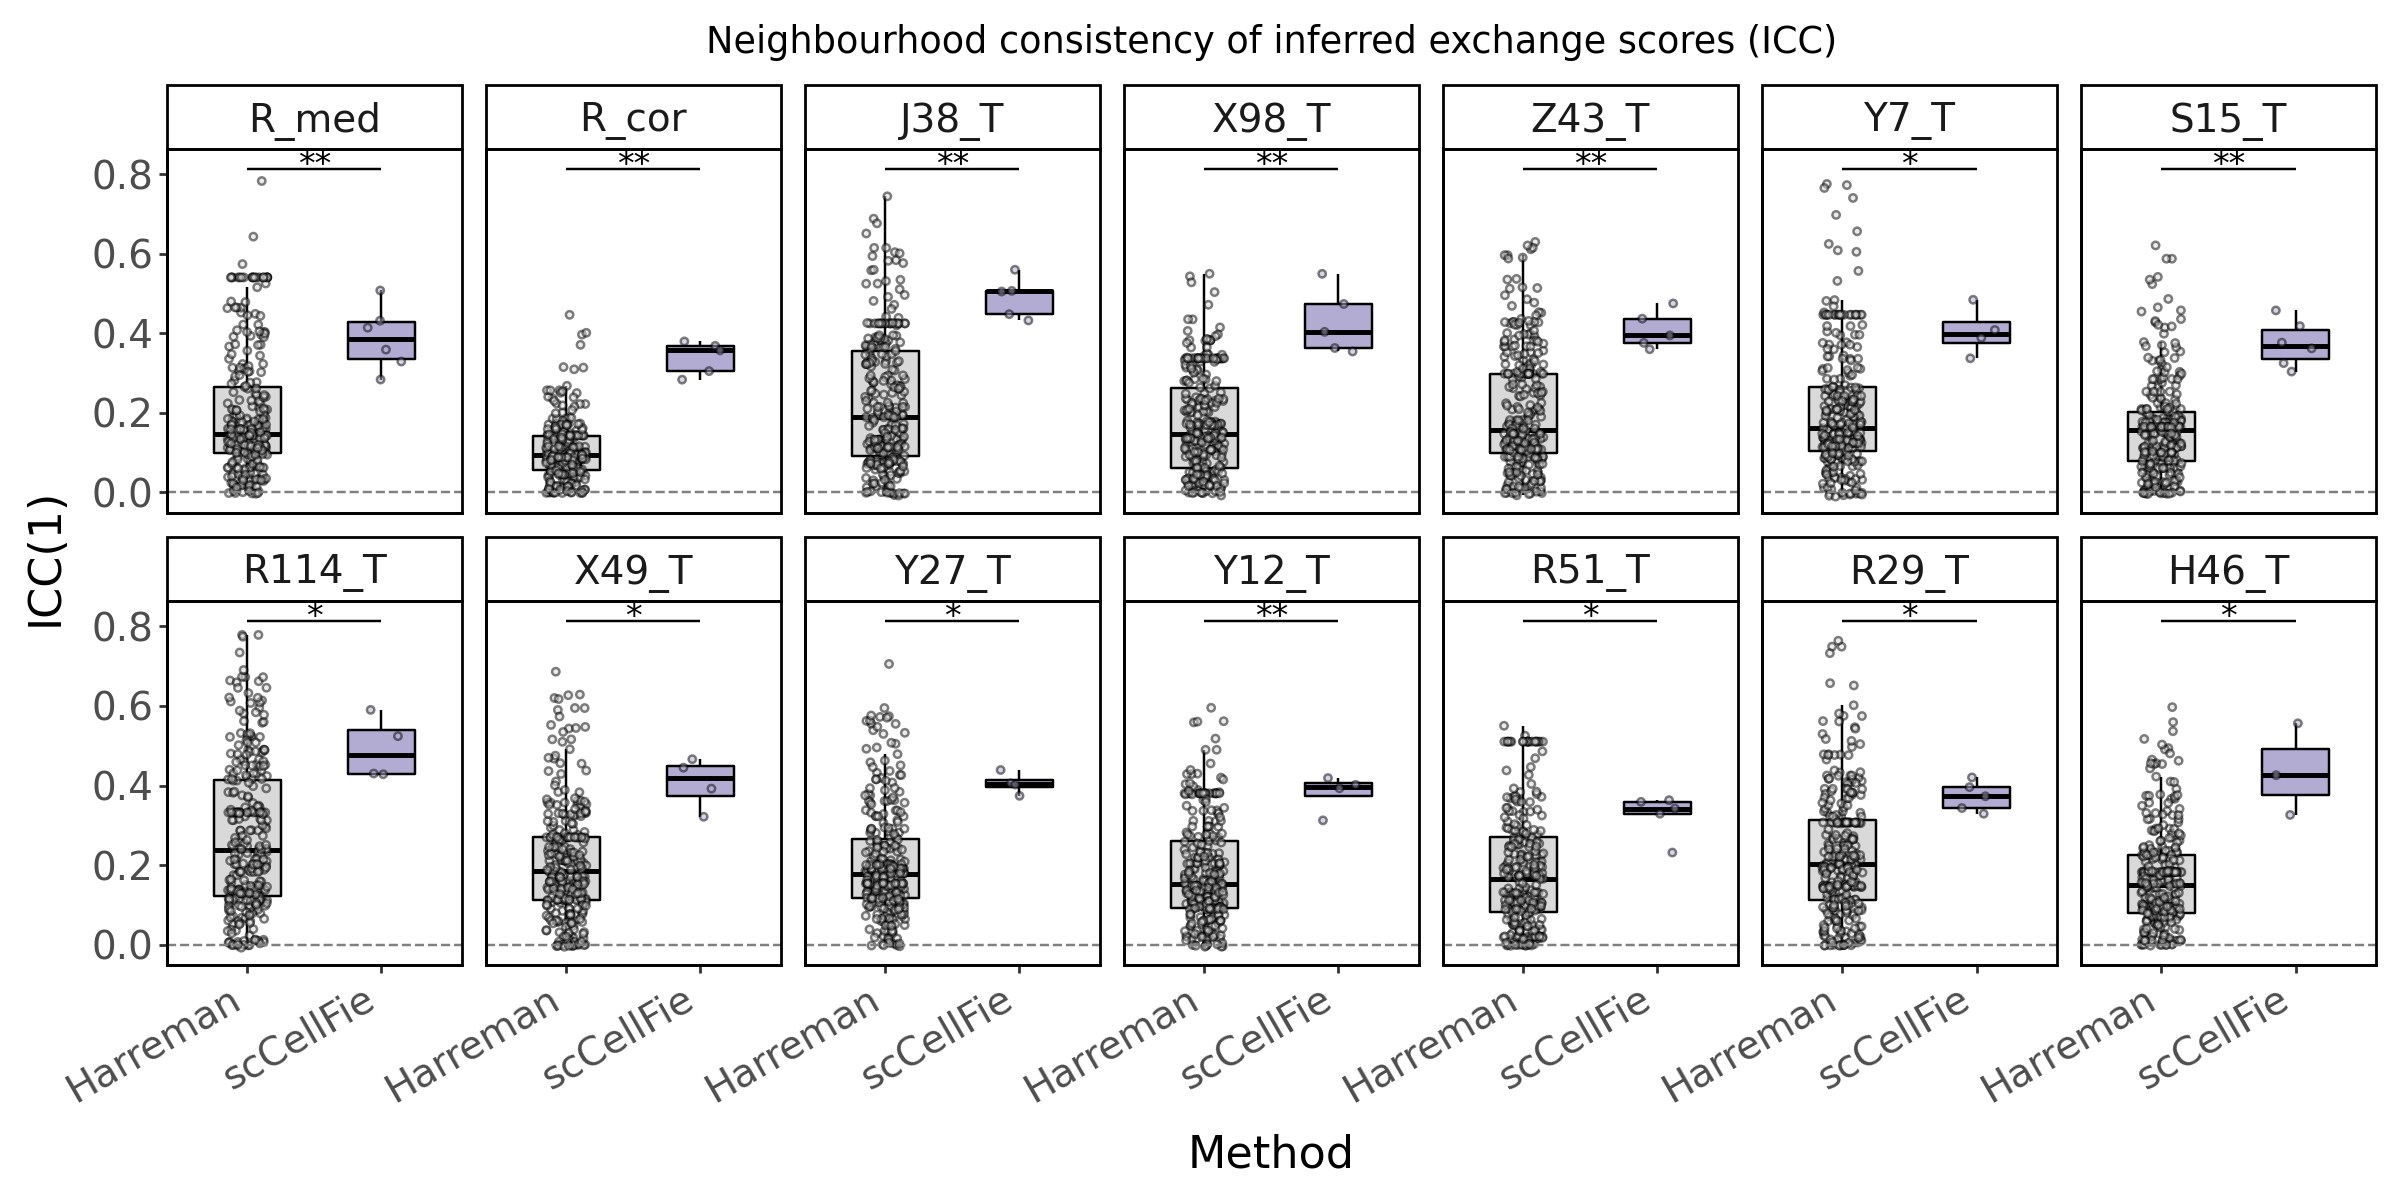

Figure saved to /home/projects/nyosef/oier/Harreman_files/Revision/Visium_RCC/plots/icc_per_sample.svg


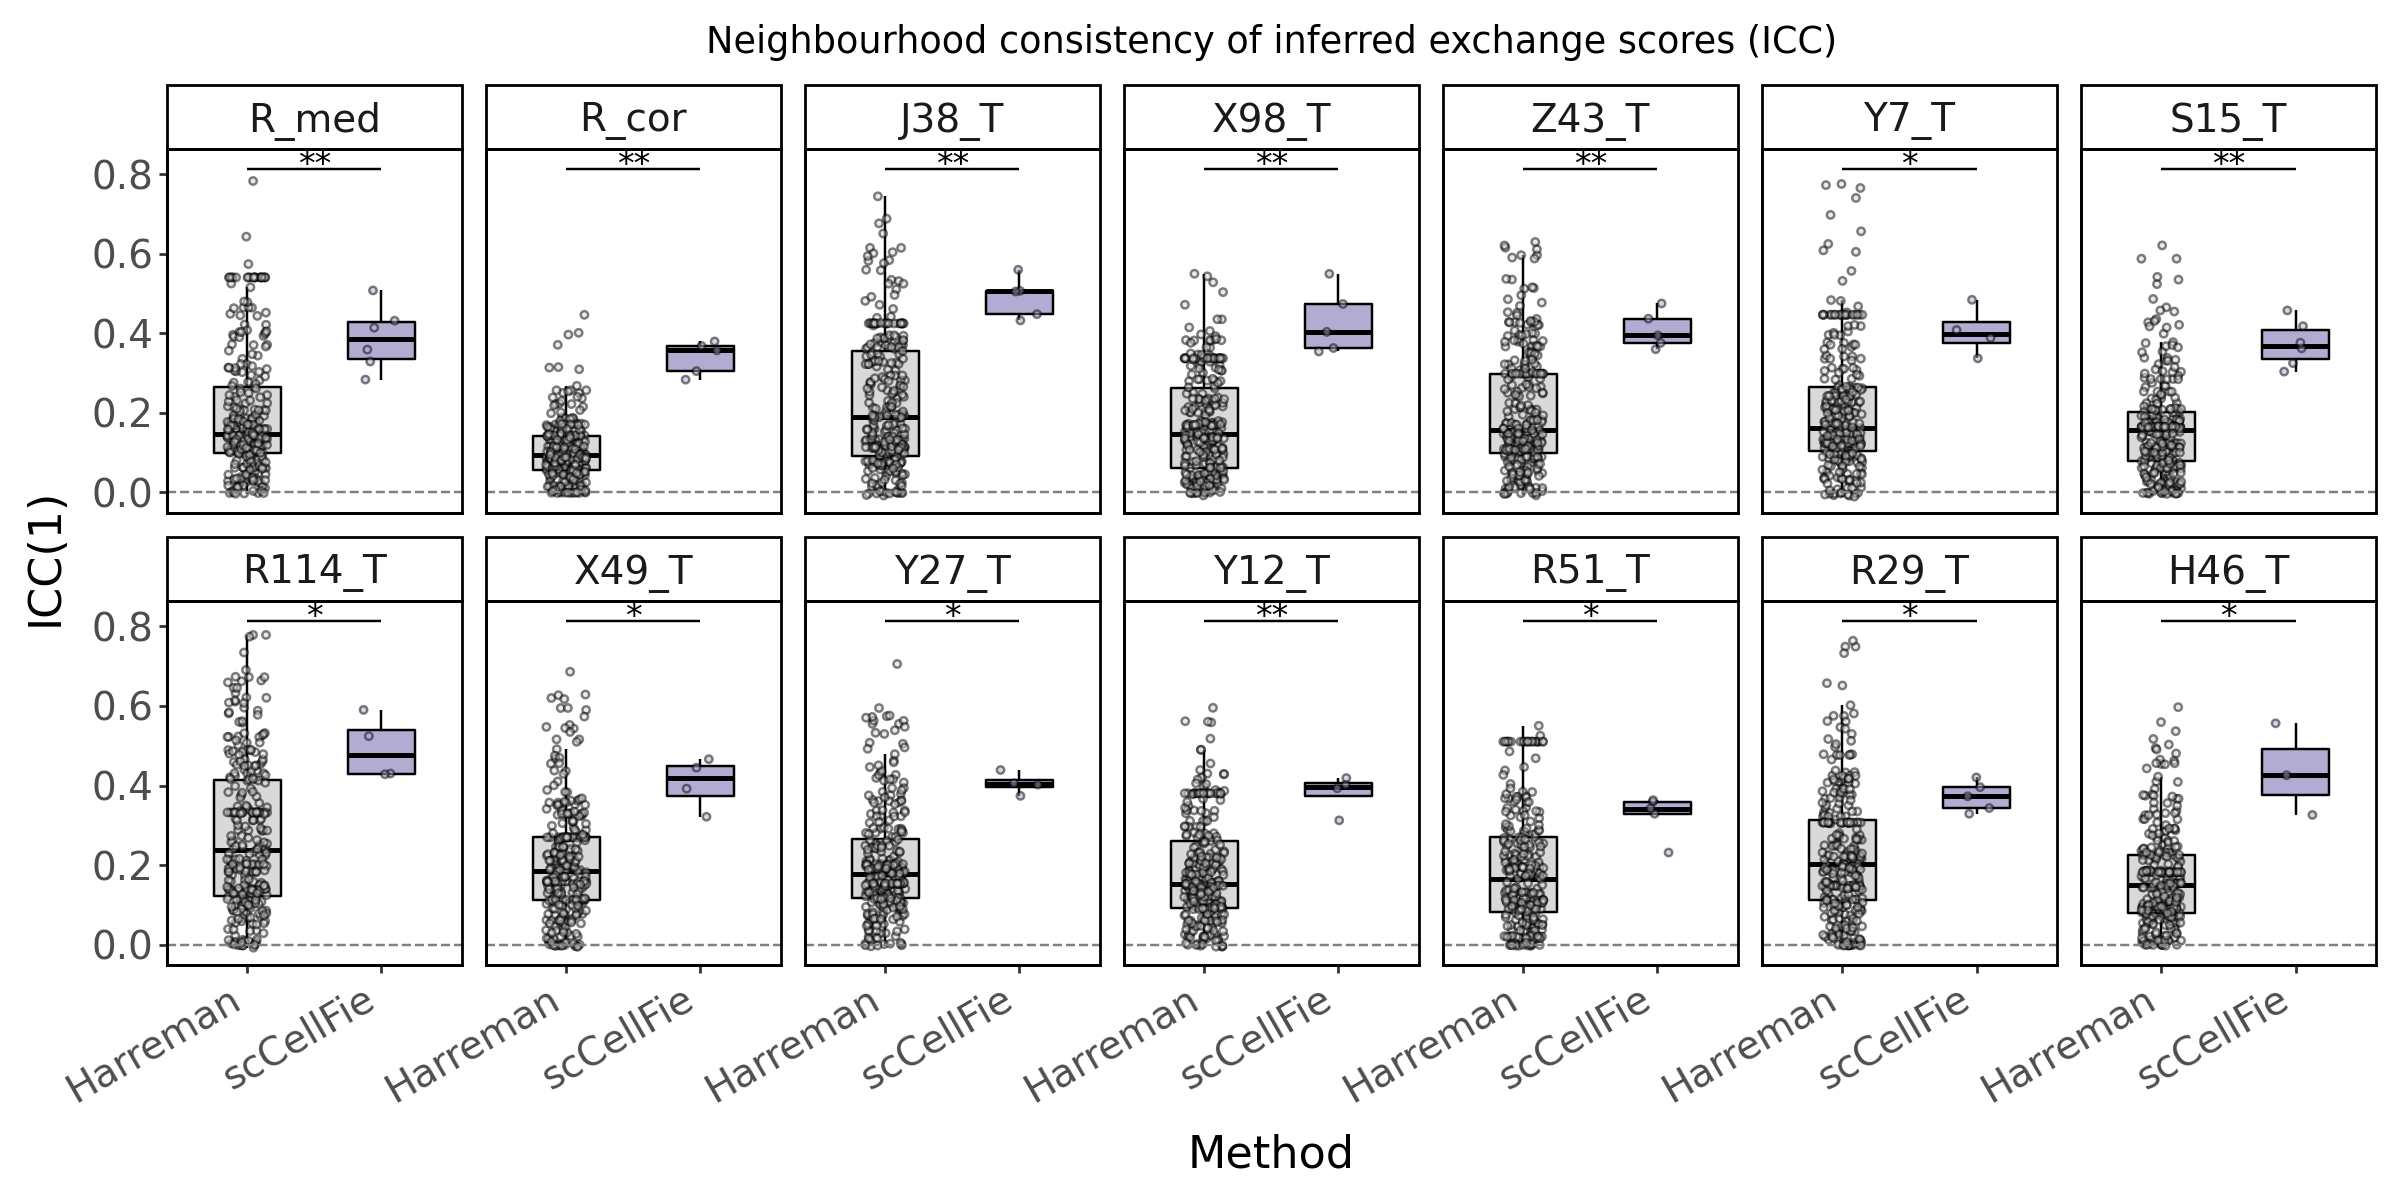

In [12]:
plot_icc(
    results_df, mwu_df,
    sample_order=SAMPLE_ORDER,
    save_path=f'{PLOTS_PATH}/icc_per_sample.svg',
)


Global Mann-Whitney U (all samples pooled):
  Harreman median ICC1  = 0.1584
  scCellFie median ICC1 = 0.3947
  U = 31744.0, p = 5.2839e-26


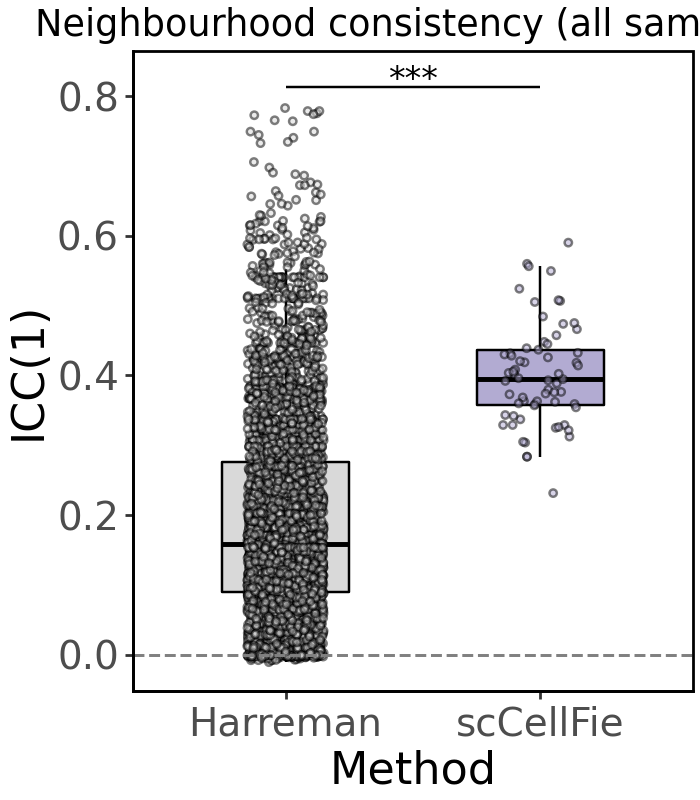

Figure saved to /home/projects/nyosef/oier/Harreman_files/Revision/Visium_RCC/plots/icc_global.svg


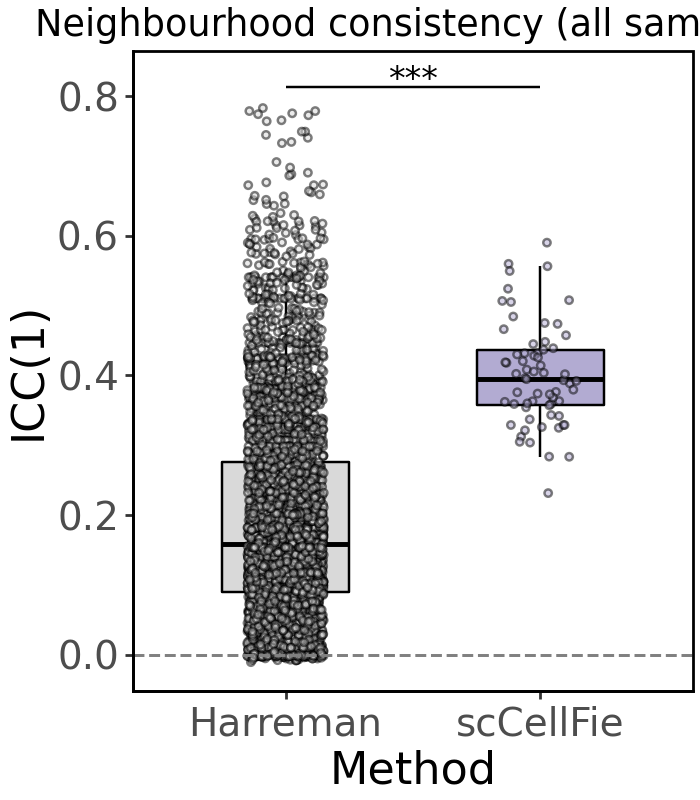

In [13]:
plot_icc_global(
    results_df, mwu_df,
    save_path=f'{PLOTS_PATH}/icc_global.svg',
)